# 13 - Phase 4 Duration Sweep

Sequentially executes notebook 12 for each target battery duration, then aggregates
and compares results across durations.

**Duration parameter** is injected via the `NB12_DURATION_H` environment variable.
Notebook 12 reads this at startup; no manual edits to nb12 are needed.

**Output files produced per duration** (by notebook 12):
- `data/processed/phase4_method_comparison_{d}h.csv` / `.json`
- `data/processed/lsmc_attribution_{d}h.json` / `.png`
- `data/processed/phase4_method_comparison_{d}h.png`
- `data/processed/executed/12_phase4_{d}h.ipynb` (executed notebook copy)

**Aggregated outputs** (produced by this notebook):
- `data/processed/phase4_all_durations_comparison.csv` / `.json`
- `data/processed/phase4_all_durations_attribution.csv` / `.json`
- `data/processed/phase4_all_durations_comparison.png`
- `data/processed/phase4_all_durations_attribution.png`


## 1  Setup


In [1]:
import os
os.environ['PHASE4_DA_FORWARD_FEATURE_MODE'] = 'efa_blocks'
os.environ['PHASE4_MAX_PARALLEL'] = '1'
os.environ['PHASE4_STALL_MINUTES'] = '12'


In [2]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
EXECUTED_DIR = PROCESSED / 'executed'
EXECUTED_DIR.mkdir(parents=True, exist_ok=True)

NB12_PATH = NOTEBOOKS_DIR / '12_phase4_method_comparison.ipynb'

# ── Sweep configuration ──────────────────────────────────────────────────────
SWEEP_DURATIONS_H = [1.0, 2.0, 3.0, 4.0]
TIMEOUT_S = 10_800   # nbconvert safety cap; child wall-time cap below controls diagnostics
CHILD_WALLTIME_LIMIT_S = float(os.environ.get('PHASE4_CHILD_MAX_MINUTES', '45')) * 60
# Kill and retry serially after this many seconds of zero status events (zmq deadlock guard)
STALL_TIMEOUT_S = float(os.environ.get('PHASE4_STALL_MINUTES', '4')) * 60
STATUS_POLL_S = float(os.environ.get('PHASE4_STATUS_POLL_S', '5'))
PROGRESS_INTERVAL_PCT = max(1.0, float(os.environ.get('PHASE4_PROGRESS_INTERVAL_PCT', '25')))

# Debug-sized child runs.  Set PHASE4_DEBUG=0 for the full 500-path medium run.
DEBUG_SWEEP = os.environ.get('PHASE4_DEBUG', '1').strip().lower() not in {'0', 'false', 'no'}
DEBUG_N_PATHS = int(os.environ.get('PHASE4_DEBUG_N_PATHS', '125'))
DEBUG_BWD_STEPS = int(os.environ.get('PHASE4_DEBUG_BWD_STEPS', '1080'))  # ~22 days at HH resolution
DEBUG_FWD_WORKERS = int(os.environ.get('PHASE4_DEBUG_FWD_WORKERS', '1'))
FORCE_RERUN = os.environ.get('PHASE4_FORCE_RERUN', '1' if DEBUG_SWEEP else '0').strip().lower() not in {'0', 'false', 'no'}

# Default to 2 workers: faster than serial, less prone to child-kernel wedges
# and CPU oversubscription than launching all durations at once on Windows.
_default_parallel = str(min(2, len(SWEEP_DURATIONS_H)))
MAX_PARALLEL_DURATIONS = int(os.environ.get('PHASE4_MAX_PARALLEL', _default_parallel))
MAX_PARALLEL_DURATIONS = max(1, min(MAX_PARALLEL_DURATIONS, len(SWEEP_DURATIONS_H)))
_RI_WORKERS_EACH_DEFAULT = max(1, min(2, ((os.cpu_count() or 2) - 2) // max(2 * MAX_PARALLEL_DURATIONS, 1)))
RI_WORKERS_EACH = int(os.environ.get('PHASE4_RI_WORKERS_EACH', _RI_WORKERS_EACH_DEFAULT))
RI_WORKERS_EACH = max(1, RI_WORKERS_EACH)

print(f'Project root : {PROJECT_ROOT}')
print(f'Notebook 12  : {NB12_PATH}  (exists={NB12_PATH.exists()})')
print(f'Executed dir : {EXECUTED_DIR}')
print(f'Durations    : {SWEEP_DURATIONS_H}')
print(f'Timeout/run  : {TIMEOUT_S/3600:.1f} h nbconvert cap; {CHILD_WALLTIME_LIMIT_S/60:.1f} min child wall cap')
print(f'Stall timeout: {STALL_TIMEOUT_S/60:.1f} min (kill+retry if no status events)')
print(f'Progress step: {PROGRESS_INTERVAL_PCT:g}% status buckets')
print(f'Max parallel : {MAX_PARALLEL_DURATIONS}')
print(f'RI workers   : {RI_WORKERS_EACH} each for DA/WD per child')
print(f'Force rerun  : {FORCE_RERUN}')
if DEBUG_SWEEP:
    print(f'Debug sweep  : ON  paths={DEBUG_N_PATHS}, bwd_steps={DEBUG_BWD_STEPS}, fwd_workers={DEBUG_FWD_WORKERS}')
else:
    print('Debug sweep  : OFF  full medium settings')

Project root : g:\My Drive\Research\BESS\bess_project
Notebook 12  : g:\My Drive\Research\BESS\bess_project\notebooks\12_phase4_method_comparison.ipynb  (exists=True)
Executed dir : g:\My Drive\Research\BESS\bess_project\data\processed\executed
Durations    : [1.0, 2.0, 3.0, 4.0]
Timeout/run  : 3.0 h nbconvert cap; 45.0 min child wall cap
Stall timeout: 12.0 min (kill+retry if no status events)
Progress step: 25% status buckets
Max parallel : 1
RI workers   : 2 each for DA/WD per child
Force rerun  : True
Debug sweep  : ON  paths=125, bwd_steps=1080, fwd_workers=1


## 2  Sequential Execution


In [3]:
import pickle as _pickle

DEBUG_BUNDLE_PATH = PROCESSED / 'sim_bundle_debug.pkl'

if DEBUG_SWEEP:
    _needed_paths = DEBUG_N_PATHS * 2 + 50   # BWD + FWD + small buffer
    _needed_steps = DEBUG_BWD_STEPS + 100    # steps + small buffer

    _regen = True
    if DEBUG_BUNDLE_PATH.exists():
        import pickle as _pk
        try:
            with DEBUG_BUNDLE_PATH.open('rb') as _f:
                _hdr = _pk.load(_f)
            if _hdr.n_paths >= _needed_paths and _hdr.n_steps >= _needed_steps:
                print(f'Debug bundle exists: {_hdr.n_paths} paths × {_hdr.n_steps} steps — reusing.')
                _regen = False
            else:
                print(f'Debug bundle too small ({_hdr.n_paths}×{_hdr.n_steps}); regenerating.')
        except Exception as _e:
            print(f'Debug bundle unreadable ({_e}); regenerating.')

    if _regen:
        import sys as _sys
        if str(PROJECT_ROOT) not in _sys.path:
            _sys.path.insert(0, str(PROJECT_ROOT))
        import numpy as _np
        from src.config import SCHWARTZ_SMITH as _SS_CFG
        from src.processes.simulate import simulate as _simulate, default_params_from_config as _dpfc
        from src.processes.schwartz_smith import SSParams as _SSP
        from src.processes.hpfc import HPFCParams as _HPFCP
        from src.processes.imbalance import ImbalanceParams as _IMBP
        from src.processes.ancillary import AncillaryParams as _ANCP
        from src.processes.bm import BMParams as _BMP
        from pathlib import Path as _Path

        def _load_json_or_default_nb13(cls, default_obj, *fnames):
            for fname in fnames:
                p = PROCESSED / fname
                if p.exists():
                    return cls.from_json(p)
            return default_obj

        _ss_d, _hpfc_d, _imb_d, _anc_d, _bm_d = _dpfc()
        _ss  = _load_json_or_default_nb13(_SSP,  _ss_d,   'ss_params.json')
        _hpfc= _load_json_or_default_nb13(_HPFCP,_hpfc_d, 'pca_params.json', 'hpfc_params.json')
        _imb = _load_json_or_default_nb13(_IMBP, _imb_d,  'imbalance_params.json')
        _anc = _load_json_or_default_nb13(_ANCP, _anc_d,  'ancillary_params.json')
        _bm  = _load_json_or_default_nb13(_BMP,  _bm_d,   'bm_params.json')

        _xi0 = _np.full(_needed_paths, _np.log(float(_SS_CFG['forward_anchor_gbp_mwh'])))
        print(f'Simulating debug bundle: {_needed_paths} paths × {_needed_steps} steps ...')
        import time as _time; _t0 = _time.time()
        _bdbundle = _simulate(_ss, _hpfc, _imb, _anc, _bm,
                              n_paths=_needed_paths, n_steps=_needed_steps,
                              seed=42, xi_0=_xi0)
        with DEBUG_BUNDLE_PATH.open('wb') as _f:
            _pickle.dump(_bdbundle, _f, protocol=4)
        print(f'Debug bundle saved in {_time.time()-_t0:.1f}s → {DEBUG_BUNDLE_PATH} '
              f'({DEBUG_BUNDLE_PATH.stat().st_size / 1e6:.1f} MB)')

    print(f'NB12 will use: {DEBUG_BUNDLE_PATH}')
else:
    print('Production mode: NB12 uses full sim_bundle.pkl')

Debug bundle unreadable (No module named 'src'); regenerating.
Simulating debug bundle: 300 paths × 1180 steps ...
Debug bundle saved in 0.4s → g:\My Drive\Research\BESS\bess_project\data\processed\sim_bundle_debug.pkl (22.7 MB)
NB12 will use: g:\My Drive\Research\BESS\bess_project\data\processed\sim_bundle_debug.pkl


In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed

STALE_DEPENDENCIES = [
    NB12_PATH,
    PROJECT_ROOT / 'src' / 'optimisation' / 'lsmc.py',
    PROJECT_ROOT / 'src' / 'optimisation' / 'dispatch.py',
    PROJECT_ROOT / 'src' / 'optimisation' / 'rolling_intrinsic.py',
    PROCESSED / 'sim_bundle.pkl',
    PROCESSED / 'imbalance_params.json',
    PROCESSED / 'ss_params.json',
    PROCESSED / 'pca_params.json',
    PROCESSED / 'ancillary_params.json',
]

def _latest_dependency_mtime() -> float:
    existing = [p.stat().st_mtime for p in STALE_DEPENDENCIES if p.exists()]
    return max(existing) if existing else 0.0

def _tail_text(path: Path, max_chars: int = 3000) -> str:
    if not path.exists():
        return ''
    text = path.read_text(encoding='utf-8', errors='replace')
    return text[-max_chars:]

def _read_status_events(path: Path) -> list[dict]:
    if not path.exists():
        return []
    events = []
    for line in path.read_text(encoding='utf-8', errors='replace').splitlines():
        if not line.strip():
            continue
        try:
            events.append(json.loads(line))
        except json.JSONDecodeError:
            continue
    return events

def _terminate_process_tree(proc: subprocess.Popen, label: str) -> None:
    if proc.poll() is not None:
        return
    print(f'[{label}] terminating child process tree (pid={proc.pid})')
    if os.name == 'nt':
        subprocess.run(
            ['taskkill', '/PID', str(proc.pid), '/T', '/F'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            check=False,
        )
    else:
        proc.terminate()

# ── Windows: fix zmq ProactorEventLoop kernel deadlock ───────────────────────
# On Windows + Python 3.12, jupyter kernels launched via 'python -m jupyter
# nbconvert --execute' can deadlock in tornado's add_reader selector thread
# registration (zmq/_future.py).  Launching through a thin wrapper that applies
# WindowsSelectorEventLoopPolicy *before* asyncio/zmq initialise prevents this.
_WIN_LAUNCH_WRAPPER = PROCESSED / '_nb_launch_win.py'
if os.name == 'nt':
    _WIN_LAUNCH_WRAPPER.write_text(
        'import asyncio, sys\n'
        'asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())\n'
        'from jupyter_core.command import main; main()\n',
        encoding='utf-8',
    )

def _nbconvert_cmd(out_nb: Path, nb_path: Path) -> list[str]:
    """Return the nbconvert launch command, applying the Windows asyncio fix."""
    if os.name == 'nt':
        prefix = [sys.executable, str(_WIN_LAUNCH_WRAPPER)]
    else:
        prefix = [sys.executable, '-m', 'jupyter']
    return prefix + [
        'nbconvert',
        '--to', 'notebook',
        '--execute',
        f'--ExecutePreprocessor.timeout={TIMEOUT_S}',
        f'--output={out_nb}',
        str(nb_path),
    ]

def _run_one_duration(dur: float, attempt: int = 1) -> tuple[str, dict]:
    label = f'{dur:g}h'
    out_nb = EXECUTED_DIR / f'12_phase4_{label}.ipynb'
    csv_out = PROCESSED / f'phase4_method_comparison_{label}.csv'
    status_path = PROCESSED / f'phase4_status_{label}.jsonl'
    log_path = PROCESSED / f'phase4_child_{label}.log'

    # Skip-check only on first attempt; retries always rerun.
    if attempt == 1:
        if csv_out.exists() and out_nb.exists() and not FORCE_RERUN:
            output_mtime = min(csv_out.stat().st_mtime, out_nb.stat().st_mtime)
            dependency_mtime = _latest_dependency_mtime()
            if output_mtime >= dependency_mtime:
                print(f'[{label}] outputs exist and are current — skipping')
                return label, {'status': 'skipped', 'elapsed_s': 0}
            print(f'[{label}] outputs are stale after code/notebook changes — re-running')
        elif csv_out.exists() and out_nb.exists() and FORCE_RERUN:
            print(f'[{label}] outputs exist but FORCE_RERUN=True — re-running')

    for path in (status_path, log_path):
        if path.exists():
            path.unlink()

    attempt_tag = f' (attempt {attempt}, serial)' if attempt > 1 else ''
    print(f'[{label}] Starting{attempt_tag}  {pd.Timestamp.now().strftime("%H:%M:%S")}')
    t0 = time.time()

    env = os.environ.copy()
    env['NB12_DURATION_H'] = str(dur)
    env['NB12_WD_UPLIFT_CAP_GBP_MWH'] = os.environ.get('PHASE4_WD_UPLIFT_CAP_GBP_MWH', '10')
    env['NB12_STATUS_PATH'] = str(status_path)
    env['NB12_PROGRESS_INTERVAL_PCT'] = f'{PROGRESS_INTERVAL_PCT:g}'
    env['NB12_DA_FORWARD_FEATURE_HH'] = os.environ.get('PHASE4_DA_FORWARD_FEATURE_HH', '48')
    env['NB12_DA_FORWARD_FEATURE_MODE'] = os.environ.get('PHASE4_DA_FORWARD_FEATURE_MODE', 'efa_blocks')
    env['NB12_IMBALANCE_SIGNAL_LAG_HH'] = os.environ.get('PHASE4_IMBALANCE_SIGNAL_LAG_HH', '1')
    env['NB12_ALLOW_ANCILLARY_STACKING'] = os.environ.get('PHASE4_ALLOW_ANCILLARY_STACKING', '0')
    env['NB12_RESERVE_SUSTAIN_H'] = os.environ.get('PHASE4_RESERVE_SUSTAIN_H', '1.0')
    env['NB12_RI_WORKERS_EACH'] = str(RI_WORKERS_EACH)
    if DEBUG_SWEEP:
        env['NB12_RI_PATHS'] = str(DEBUG_N_PATHS)
        env['NB12_BWD_PATHS'] = str(DEBUG_N_PATHS)
        env['NB12_FWD_PATHS'] = str(DEBUG_N_PATHS)
        env['NB12_BWD_STEPS'] = str(DEBUG_BWD_STEPS)
        env['NB12_FWD_WORKERS'] = str(DEBUG_FWD_WORKERS)
        env['NB12_BUNDLE_PATH'] = str(DEBUG_BUNDLE_PATH)
    # Serial retry: force single forward worker to avoid zmq fan-out deadlock
    if attempt > 1:
        env['NB12_FWD_WORKERS'] = '1'

    cmd = _nbconvert_cmd(out_nb, NB12_PATH)

    last_bucket_by_phase: dict[str, float] = {}
    last_heartbeat_s = 0.0
    timed_out = False
    stalled = False
    stall_elapsed_s = 0.0
    with log_path.open('w', encoding='utf-8') as log_fh:
        proc = subprocess.Popen(
            cmd,
            env=env,
            stdout=log_fh,
            stderr=subprocess.STDOUT,
            text=True,
        )
        while proc.poll() is None:
            elapsed = time.time() - t0
            printed_event = False
            events = _read_status_events(status_path)
            for event in events:
                phase = str(event.get('phase', 'unknown'))
                pct = float(event.get('progress_pct', 0.0))
                bucket = 100.0 if pct >= 100.0 else int(pct // PROGRESS_INTERVAL_PCT) * PROGRESS_INTERVAL_PCT
                if bucket > last_bucket_by_phase.get(phase, -1):
                    last_bucket_by_phase[phase] = bucket
                    step = int(event.get('step', 0))
                    total = int(event.get('total_steps', 0))
                    ev_elapsed = float(event.get('elapsed_s', elapsed))
                    print(
                        f'[{label}] {phase:8s} {bucket:3.0f}%  '
                        f'({step:,}/{total:,} steps, {ev_elapsed/60:.1f} min)'
                    )
                    printed_event = True
            if printed_event:
                last_heartbeat_s = elapsed
            elif elapsed - last_heartbeat_s >= 60.0:
                last_heartbeat_s = elapsed
                if events:
                    latest = events[-1]
                    latest_phase = str(latest.get('phase', 'unknown'))
                    latest_pct = float(latest.get('progress_pct', 0.0))
                    latest_age = elapsed - float(latest.get('elapsed_s', elapsed))
                    print(
                        f'[{label}] still running {elapsed/60:.1f} min; '
                        f'last status {latest_phase} {latest_pct:.0f}% '
                        f'({latest_age/60:.1f} min ago)'
                    )
                else:
                    print(f'[{label}] still running {elapsed/60:.1f} min; no status yet')
            # Stall guard: no status events at all after STALL_TIMEOUT_S → zmq deadlock suspected
            if not events and elapsed >= STALL_TIMEOUT_S and attempt == 1:
                stalled = True
                stall_elapsed_s = elapsed
                print(
                    f'[{label}] STALL detected: no status after {elapsed/60:.1f} min '
                    f'(zmq deadlock suspected) — killing, will retry serially'
                )
                _terminate_process_tree(proc, label)
                break
            if elapsed >= CHILD_WALLTIME_LIMIT_S:
                timed_out = True
                print(f'[{label}] TIME LIMIT {CHILD_WALLTIME_LIMIT_S/60:.1f} min reached')
                _terminate_process_tree(proc, label)
                break
            time.sleep(STATUS_POLL_S)

        try:
            returncode = proc.wait(timeout=30)
        except subprocess.TimeoutExpired:
            _terminate_process_tree(proc, label)
            returncode = proc.wait(timeout=30)

    elapsed = time.time() - t0

    # Stall retry: relaunch serially with NB12_FWD_WORKERS=1
    if stalled and attempt == 1:
        time.sleep(3)
        print(f'[{label}] Retrying serially (attempt=2, NB12_FWD_WORKERS=1)...')
        label_ret, result_ret = _run_one_duration(dur, attempt=2)
        result_ret['stall_detected'] = True
        result_ret['stall_elapsed_s'] = round(stall_elapsed_s, 1)
        return label_ret, result_ret

    status = 'timeout' if timed_out else ('ok' if returncode == 0 else 'failed')

    if returncode == 0 and not timed_out:
        print(f'[{label}] DONE in {elapsed/60:.1f} min  →  {out_nb.name}')
    else:
        print(f'[{label}] {status.upper()} (rc={returncode}) after {elapsed/60:.1f} min')
        print(f'--- child log tail ({log_path.name}) ---')
        print(_tail_text(log_path, 3000))

    return label, {
        'status': status,
        'elapsed_s': round(elapsed, 1),
        'output_nb': str(out_nb),
        'status_path': str(status_path),
        'log_path': str(log_path),
        'returncode': returncode,
    }


# Run all durations in parallel — each is a separate subprocess on its own core.
# Wall-clock time → slowest single duration instead of sum of all durations.
print(f'Launching {len(SWEEP_DURATIONS_H)} durations in parallel...\n')
t_sweep_start = time.time()

run_log = {}
with ThreadPoolExecutor(max_workers=MAX_PARALLEL_DURATIONS) as pool:
    futures = {pool.submit(_run_one_duration, dur): dur for dur in SWEEP_DURATIONS_H}
    for fut in as_completed(futures):
        label, result = fut.result()
        run_log[label] = result

print(f'\n\nRun summary  (total wall-clock: {(time.time()-t_sweep_start)/60:.1f} min):')
for label in [f'{d:g}h' for d in SWEEP_DURATIONS_H]:
    r = run_log.get(label, {})
    mins = r.get('elapsed_s', 0) / 60
    stall_tag = '  [stall+retry]' if r.get('stall_detected') else ''
    print(f'  {label:5s}  {r.get("status","?"):8s}  {mins:.1f} min{stall_tag}')

# Save run log
with open(PROCESSED / 'phase4_sweep_run_log.json', 'w') as f:
    json.dump(run_log, f, indent=2)
print('Saved: phase4_sweep_run_log.json')

Launching 4 durations in parallel...

[1h] outputs exist but FORCE_RERUN=True — re-running
[1h] Starting  10:18:03
[1h] startup   25%  (1/4 steps, 0.0 min)
[1h] still running 1.2 min; last status startup 25% (1.2 min ago)
[1h] rolling_intrinsic_done  75%  (3/4 steps, 1.7 min)
[1h] lsmc_fwd_done 100%  (4/4 steps, 1.9 min)
[1h] DONE in 2.2 min  →  12_phase4_1h.ipynb
[2h] outputs exist but FORCE_RERUN=True — re-running
[2h] Starting  10:20:13
[2h] startup   25%  (1/4 steps, 0.0 min)
[2h] still running 1.2 min; last status startup 25% (1.2 min ago)
[2h] rolling_intrinsic_done  75%  (3/4 steps, 1.7 min)
[2h] lsmc_fwd_done 100%  (4/4 steps, 1.9 min)
[2h] DONE in 2.3 min  →  12_phase4_2h.ipynb
[3h] outputs exist but FORCE_RERUN=True — re-running
[3h] Starting  10:22:29
[3h] startup   25%  (1/4 steps, 0.0 min)
[3h] still running 1.2 min; last status startup 25% (1.2 min ago)
[3h] rolling_intrinsic_done  75%  (3/4 steps, 1.7 min)
[3h] lsmc_fwd_done 100%  (4/4 steps, 1.9 min)
[3h] DONE in 2.2 mi

## 3  Load and Aggregate Results


In [5]:
all_comparison  = []
all_attribution = []
missing = []

for dur in SWEEP_DURATIONS_H:
    label = f'{dur:g}h'

    csv_path = PROCESSED / f'phase4_method_comparison_{label}.csv'
    if csv_path.exists():
        all_comparison.append(pd.read_csv(csv_path))
        print(f'  loaded {csv_path.name}')
    else:
        missing.append(str(csv_path.name))
        print(f'  MISSING {csv_path.name}')

    attr_path = PROCESSED / f'lsmc_attribution_{label}.json'
    if attr_path.exists():
        with open(attr_path) as fh:
            rows = json.load(fh)
        # ensure duration_h is present (nb12 now writes it; older files may not)
        for r in rows:
            r.setdefault('duration_h', dur)
        all_attribution.extend(rows)
        print(f'  loaded {attr_path.name}')
    else:
        missing.append(str(attr_path.name))
        print(f'  MISSING {attr_path.name}')

if missing:
    print(f'\nWARNING: {len(missing)} files missing — re-run section 2 to generate them')

df_cmp  = pd.concat(all_comparison,  ignore_index=True) if all_comparison  else pd.DataFrame()
df_attr = pd.DataFrame(all_attribution) if all_attribution else pd.DataFrame()

print(f'\nComparison table : {len(df_cmp)} rows,  {df_cmp["duration_h"].nunique() if len(df_cmp) else 0} durations')
print(f'Attribution table: {len(df_attr)} rows')
df_cmp.head(10)


  loaded phase4_method_comparison_1h.csv


  loaded lsmc_attribution_1h.json
  loaded phase4_method_comparison_2h.csv
  loaded lsmc_attribution_2h.json
  loaded phase4_method_comparison_3h.csv
  loaded lsmc_attribution_3h.json
  loaded phase4_method_comparison_4h.csv
  loaded lsmc_attribution_4h.json

Comparison table : 20 rows,  4 durations
Attribution table: 28 rows


,duration_h,run_mode,method,value_gbp_horizon_mean,value_gbp_annualized_mean,gbp_per_mw_year,n_paths,window_hh,gate_hh,notes,value_gbp_annualized_m,gbp_per_mw_year_k,p5_ann_m,p95_ann_m
0,1.0,medium,Initial hourly intrinsic,9.706158e+05,9.706158e+05,9706.157583,1,24,24,HPFC hourly daily LP; 5-year annual avg gross ...,0.970616,9.706158,0.970616,0.970616
1,1.0,medium,DA rolling intrinsic,1.002085e+05,1.625604e+06,16256.044743,125,48,8,HPFC-anchored simulated paths (125 paths); rol...,1.625604,16.256045,1.254954,1.996255
2,1.0,medium,WD rolling intrinsic,1.646161e+05,2.670439e+06,26704.394224,125,48,8,HPFC-anchored simulated paths (125 paths); rol...,2.670439,26.704394,2.472370,2.868509
3,1.0,medium,Forward simulation (LSMC),8.909861e+04,1.445377e+06,14453.774778,125,0,0,Non-anticipative LSMC policy on 125 paths + an...,1.445377,14.453775,1.321452,1.569303
4,1.0,medium,Perfect foresight (DA energy),9.623667e+04,1.561173e+06,15611.726645,125,1080,1080,Full-horizon LP on 125 sampled HPFC-anchored D...,1.561173,15.611727,1.213908,1.908438
5,2.0,medium,Initial hourly intrinsic,1.857417e+06,1.857417e+06,18574.173918,1,24,24,HPFC hourly daily LP; 5-year annual avg gross ...,1.857417,18.574174,1.857417,1.857417
6,2.0,medium,DA rolling intrinsic,1.908552e+05,3.096095e+06,30960.949683,125,48,8,HPFC-anchored simulated paths (125 paths); rol...,3.096095,30.960950,2.389349,3.802841
7,2.0,medium,WD rolling intrinsic,2.753964e+05,4.467542e+06,44675.424074,125,48,8,HPFC-anchored simulated paths (125 paths); rol...,4.467542,44.675424,3.986588,4.948497
8,2.0,medium,Forward simulation (LSMC),2.315922e+05,3.756940e+06,37569.397443,125,0,0,Non-anticipative LSMC policy on 125 paths + an...,3.756940,37.569397,3.508890,4.004990
9,2.0,medium,Perfect foresight (DA energy),1.828550e+05,2.966314e+06,29663.139560,125,1080,1080,Full-horizon LP on 125 sampled HPFC-anchored D...,2.966314,29.663140,2.306603,3.626025


## 4  Method Comparison Across Durations


Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_comparison.png


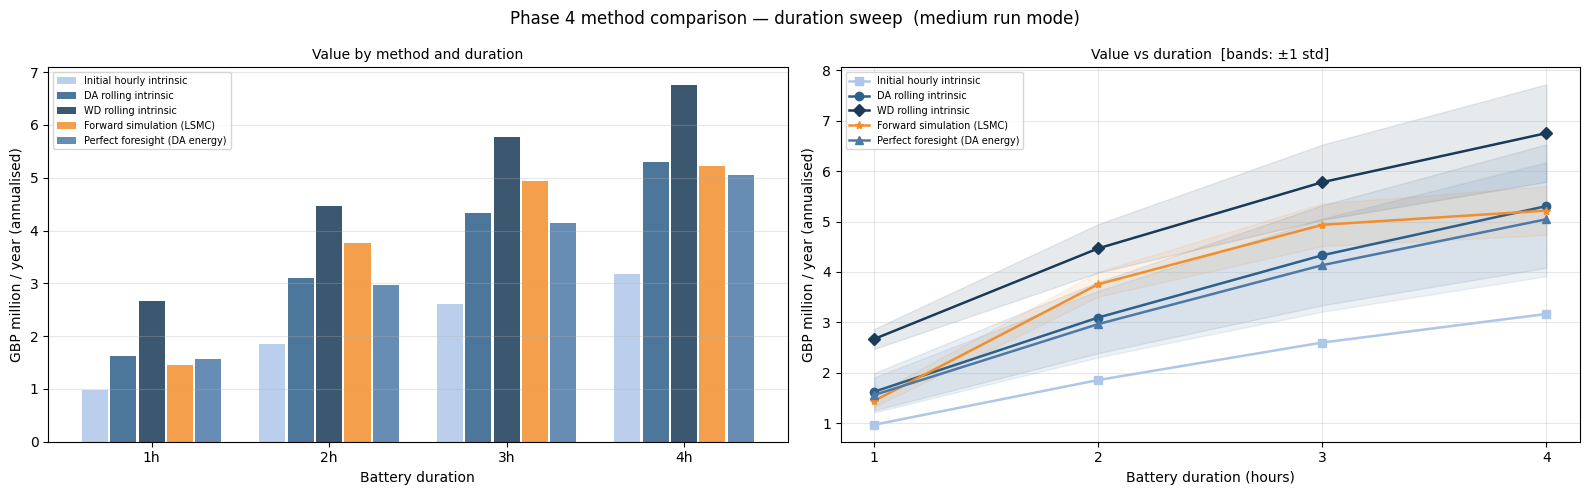


LSMC value (£m/year) by method and duration:
                                 1h    2h    3h    4h
method                                               
Initial hourly intrinsic       0.97  1.86  2.60  3.17
DA rolling intrinsic           1.63  3.10  4.33  5.31
WD rolling intrinsic           2.67  4.47  5.78  6.75
Forward simulation (LSMC)      1.45  3.76  4.93  5.22
Perfect foresight (DA energy)  1.56  2.97  4.13  5.04


In [6]:
METHODS = [
    'Initial hourly intrinsic',
    'DA rolling intrinsic',
    'WD rolling intrinsic',
    'Forward simulation (LSMC)',
    'Perfect foresight (DA energy)',
]
METHOD_COLOURS = {
    'Initial hourly intrinsic':      '#aec7e8',
    'DA rolling intrinsic':          '#2c5f8a',
    'WD rolling intrinsic':          '#1a3a57',
    'Forward simulation (LSMC)':     '#f28e2b',
    'Perfect foresight (DA energy)': '#4e79a7',
}
METHOD_MARKERS = {
    'Initial hourly intrinsic':      's',
    'DA rolling intrinsic':          'o',
    'WD rolling intrinsic':          'D',
    'Forward simulation (LSMC)':     '*',
    'Perfect foresight (DA energy)': '^',
}

durations_avail = sorted(df_cmp['duration_h'].unique()) if len(df_cmp) else []

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 4 method comparison — duration sweep  (medium run mode)', fontsize=12)

# ── Left: grouped bar by duration ────────────────────────────────────────────
ax = axes[0]
n_dur = len(durations_avail)
n_met = len(METHODS)
x     = np.arange(n_dur)
width = 0.8 / n_met

for i, method in enumerate(METHODS):
    sub  = df_cmp[df_cmp['method'] == method].set_index('duration_h')
    vals = [float(sub.loc[d, 'value_gbp_annualized_m']) if d in sub.index else np.nan for d in durations_avail]
    offsets = x + i * width - (n_met - 1) * width / 2
    ax.bar(offsets, vals, width * 0.92,
           color=METHOD_COLOURS.get(method, '#888888'), alpha=0.85, label=method)

ax.set_xticks(x)
ax.set_xticklabels([f'{d:g}h' for d in durations_avail])
ax.set_xlabel('Battery duration')
ax.set_ylabel('GBP million / year (annualised)')
ax.set_title('Value by method and duration', fontsize=10)
ax.legend(fontsize=7, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# ── Right: line chart — value vs duration ────────────────────────────────────
ax = axes[1]
for method in METHODS:
    sub = df_cmp[df_cmp['method'] == method].sort_values('duration_h')
    if sub.empty:
        continue
    col = METHOD_COLOURS.get(method, '#888888')
    mrk = METHOD_MARKERS.get(method, 'o')
    ax.plot(sub['duration_h'], sub['value_gbp_annualized_m'],
            marker=mrk, linewidth=1.8, markersize=6, color=col, label=method)
    if 'p5_ann_m' in sub.columns and 'p95_ann_m' in sub.columns:
        ax.fill_between(sub['duration_h'],
                        sub['p5_ann_m'], sub['p95_ann_m'],
                        alpha=0.10, color=col)

ax.set_xlabel('Battery duration (hours)')
ax.set_ylabel('GBP million / year (annualised)')
ax.set_title('Value vs duration  [bands: ±1 std]', fontsize=10)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)
if durations_avail:
    ax.set_xticks(durations_avail)

fig.tight_layout()
out_cmp_png = PROCESSED / 'phase4_all_durations_comparison.png'
fig.savefig(out_cmp_png, dpi=140, bbox_inches='tight')
print(f'Saved: {out_cmp_png}')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
if len(df_cmp):
    pivot = df_cmp.pivot_table(
        index='method', columns='duration_h',
        values='value_gbp_annualized_m', aggfunc='first',
    ).reindex(METHODS)
    pivot.columns = [f'{c:g}h' for c in pivot.columns]
    print('\nLSMC value (£m/year) by method and duration:')
    print(pivot.round(2).to_string())


## 5  LSMC Attribution Across Durations


Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_attribution.png


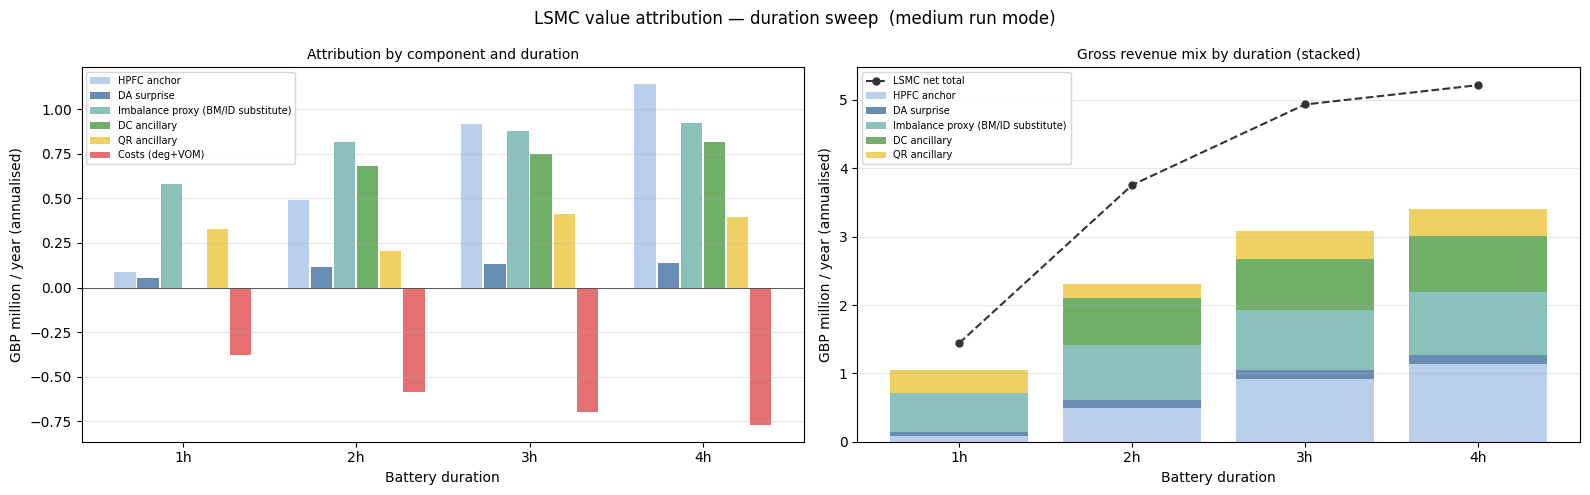


Attribution share (% of gross revenue):
                                      1h    2h    3h    4h
component                                                 
HPFC anchor                          8.0  15.5  21.7  25.6
DA surprise                          5.1   3.7   3.1   3.1
Imbalance proxy (BM/ID substitute)  54.4  25.7  20.7  20.7
DC ancillary                         0.0  21.5  17.6  18.4
QR ancillary                        31.1   6.5   9.7   8.9


In [7]:
COMPONENTS_ORD = ['HPFC anchor', 'DA surprise', 'Imbalance proxy (BM/ID substitute)', 'DC ancillary', 'QR ancillary', 'Costs (deg+VOM)']
COMP_COLOURS = {
    'HPFC anchor':      '#aec7e8',
    'DA surprise':      '#4e79a7',
    'Imbalance proxy (BM/ID substitute)': '#76b7b2',
    'DC ancillary':     '#59a14f',
    'QR ancillary':     '#edc948',
    'Costs (deg+VOM)':  '#e15759',
}

if df_attr.empty:
    print('No attribution data loaded — skipping chart')
else:
    dur_list = sorted(df_attr['duration_h'].unique())
    x        = np.arange(len(dur_list))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('LSMC value attribution — duration sweep  (medium run mode)', fontsize=12)

    # ── Left: grouped bar — component mean by duration ────────────────────────
    ax = axes[0]
    n_comp = len(COMPONENTS_ORD)
    width  = 0.8 / n_comp

    for i, comp in enumerate(COMPONENTS_ORD):
        sub  = df_attr[df_attr['component'] == comp].set_index('duration_h')
        vals = [float(sub.loc[d, 'mean_m']) if d in sub.index else np.nan for d in dur_list]
        offsets = x + i * width - (n_comp - 1) * width / 2
        ax.bar(offsets, vals, width * 0.92,
               color=COMP_COLOURS.get(comp, '#888'), alpha=0.85, label=comp)

    ax.axhline(0, color='#555', linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{d:g}h' for d in dur_list])
    ax.set_xlabel('Battery duration')
    ax.set_ylabel('GBP million / year (annualised)')
    ax.set_title('Attribution by component and duration', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    # ── Right: stacked bar — gross revenue mix by duration ────────────────────
    ax    = axes[1]
    gross = [c for c in COMPONENTS_ORD if c != 'Costs (deg+VOM)']
    bot   = np.zeros(len(dur_list))

    for comp in gross:
        sub  = df_attr[df_attr['component'] == comp].set_index('duration_h')
        vals = np.array([
            max(float(sub.loc[d, 'mean_m']), 0.0) if d in sub.index else 0.0
            for d in dur_list
        ])
        ax.bar(x, vals, bottom=bot,
               color=COMP_COLOURS[comp], alpha=0.85, label=comp)
        bot += vals

    # Overlay total LSMC line
    if len(df_cmp):
        lsmc_sub = df_cmp[df_cmp['method'] == 'Forward simulation (LSMC)'].set_index('duration_h')
        totals   = [float(lsmc_sub.loc[d, 'value_gbp_annualized_m']) if d in lsmc_sub.index else np.nan
                    for d in dur_list]
        ax.plot(x, totals, 'o--', color='#333333', linewidth=1.5, markersize=5, label='LSMC net total')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{d:g}h' for d in dur_list])
    ax.set_xlabel('Battery duration')
    ax.set_ylabel('GBP million / year (annualised)')
    ax.set_title('Gross revenue mix by duration (stacked)', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    fig.tight_layout()
    out_attr_png = PROCESSED / 'phase4_all_durations_attribution.png'
    fig.savefig(out_attr_png, dpi=140, bbox_inches='tight')
    print(f'Saved: {out_attr_png}')
    plt.show()

    # Attribution share table
    print('\nAttribution share (% of gross revenue):')
    attr_pivot = df_attr[df_attr['component'].isin(gross)].pivot_table(
        index='component', columns='duration_h',
        values='pct_of_gross', aggfunc='first',
    ).reindex([c for c in COMPONENTS_ORD if c in gross])
    attr_pivot.columns = [f'{c:g}h' for c in attr_pivot.columns]
    print(attr_pivot.round(1).to_string())


## 6  Save Combined Outputs


In [8]:
saved_outputs = []

def _save_csv_json(frame: pd.DataFrame, stem: str) -> None:
    out_csv = PROCESSED / f'{stem}.csv'
    frame.to_csv(out_csv, index=False)
    saved_outputs.append(out_csv)
    print(f'Saved: {out_csv}')

    out_json = PROCESSED / f'{stem}.json'
    frame.to_json(out_json, orient='records', indent=2)
    saved_outputs.append(out_json)
    print(f'Saved: {out_json}')

if len(df_cmp):
    _save_csv_json(df_cmp, 'phase4_all_durations_comparison')

if len(df_attr):
    _save_csv_json(df_attr, 'phase4_all_durations_attribution')

missing = [p for p in saved_outputs if not p.exists() or p.stat().st_size == 0]
if missing:
    raise FileNotFoundError('Save verification failed: ' + ', '.join(str(p) for p in missing))

print(f'\nAll outputs saved and verified ({len(saved_outputs)} files).')


Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_comparison.csv
Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_comparison.json
Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_attribution.csv
Saved: g:\My Drive\Research\BESS\bess_project\data\processed\phase4_all_durations_attribution.json

All outputs saved and verified (4 files).
